In [1]:
import numpy as np 
import netCDF4 as nc 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt 
import geopandas as gpd
import matplotlib.ticker as mticker
from shapely.geometry import Point
from rasterio.features import geometry_mask
from affine import Affine
import xarray as xr 
import pandas as pd 
import json

### GFEI

In [35]:
bound_permian = gpd.read_file(r"shapefiles/Boundary_PermianBasin_StudyArea_NAD27.shp")
bound_state = gpd.read_file(r"shapefiles/Boundary_State_NAD27.shp")
bound_permian = bound_permian.drop(bound_permian.index[1])
bound_permian = bound_permian.to_crs("EPSG:4326")

In [36]:
geoms = bound_permian.to_crs("EPSG:4326")["geometry"].values

In [37]:
GFEI = nc.Dataset(r"Global_Fuel_Exploitation_Inventory_v3_2020_Total_Fuel_Exploitation.nc",'r')

In [38]:
GFEI_area = GFEI.variables["area"][:]
GFEI_value = GFEI.variables["Total_Fuel_Exploitation"][:]
GFEI_lat = GFEI.variables["lat"][:]
GFEI_lon = GFEI.variables["lon"][:]
print(GFEI.variables)
GFEI.close()

{'area': <class 'netCDF4._netCDF4.Variable'>
float64 area(lat, lon)
    _FillValue: nan
    Units: square meters
unlimited dimensions: 
current shape = (1800, 3600)
filling on, 'Total_Fuel_Exploitation': <class 'netCDF4._netCDF4.Variable'>
float64 Total_Fuel_Exploitation(lat, lon)
    _FillValue: nan
    StandardName: emissions
    LongName: Annual methane emissions from Total_Fuel_Exploitation
    Units: Mg a-1 km-2
unlimited dimensions: 
current shape = (1800, 3600)
filling on, 'lat': <class 'netCDF4._netCDF4.Variable'>
float64 lat(lat)
    _FillValue: nan
    LongName: Degrees North Latitude
unlimited dimensions: 
current shape = (1800,)
filling on, 'lon': <class 'netCDF4._netCDF4.Variable'>
float64 lon(lon)
    _FillValue: nan
    LongName: Degrees West Longitude
unlimited dimensions: 
current shape = (3600,)
filling on}


In [39]:
GFEI_value = GFEI_value.filled(np.nan)
GFEI_area = GFEI_area * (10**-6) # convert km^2 to m^2
GFEI_value = GFEI_value * 1000 # Mg a-1 km-2 to kg a-1 km-2 
GFEI_kg = GFEI_value * GFEI_area # unit: kg a-1 

In [40]:
nrows, ncols = GFEI_value.shape
west, east = GFEI_lon.min(), GFEI_lon.max()
south, north = GFEI_lat.min(), GFEI_lat.max()

xres = (east - west) / ncols
yres = (north - south) / nrows
transform = Affine.translation(west, south) * Affine.scale(xres, yres)

In [41]:
xres

np.float64(0.09997222222222221)

In [42]:
yres

np.float64(0.09994444444444445)

In [43]:
# Step 3: Create mask (True outside, False inside)
mask = geometry_mask(
    geometries=geoms,
    out_shape=GFEI_kg.shape,
    transform=transform,
    invert=True  # invert=True means: True where inside the polygon
)

In [44]:
GFEI_unc = nc.Dataset(r"Global_Fuel_Exploitation_Inventory_Total_Fuel_Exploitation_rsd.nc",'r')
unc = GFEI_unc.variables["rsd"][:]
unc_masked = np.where(mask,unc, np.nan)

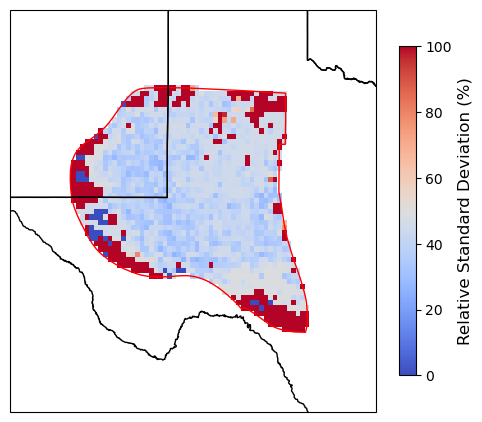

In [45]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree()})
img = ax.imshow(
    unc_masked*100,
    extent=[west, east, south, north],
    origin='lower',
    transform=ccrs.PlateCarree(),
    cmap='coolwarm'
)

# Add boundary overlays
bound_permian.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1, transform=ccrs.PlateCarree())
bound_state.to_crs("EPSG:4326").plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree())

# Colorbar and labels
cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label("Relative Standard Deviation (%)", fontsize=12)

# Zoom in on Permian
ax.set_xlim(-105.5-1, -99.5+1)
ax.set_ylim(29-1, 34.5+1)

plt.tight_layout()

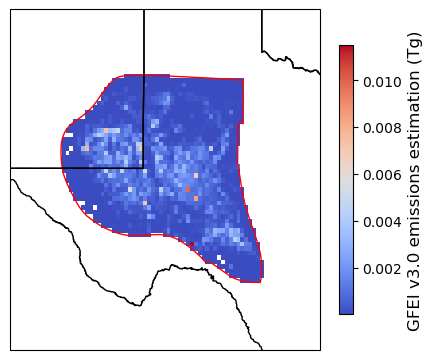

In [48]:
GFEI_masked = np.where(mask,GFEI_kg, np.nan)
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree()})
img = ax.imshow(
    GFEI_masked*10**-9,
    extent=[west, east, south, north],
    origin='lower',
    transform=ccrs.PlateCarree(),
    cmap='coolwarm'
)

# Add boundary overlays
bound_permian.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1, transform=ccrs.PlateCarree())
bound_state.to_crs("EPSG:4326").plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree())

# Colorbar and labels
cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label("GFEI v3.0 emissions estimation (Tg)", fontsize=12)

# Zoom in on Permian
ax.set_xlim(-105.5-1, -99.5+1)
ax.set_ylim(29-1, 34.5+1)

plt.savefig(r"E:\emission_event\Emission-Estimation-Using-Emission-Events\GFEI.png", dpi=600)

In [15]:
np.sqrt(np.nanmean(unc_masked ** 2))

np.float32(0.55287176)

### Event Estimation 

In [17]:
# Load sources 
features = [] 
with open("CM_sources.json", 'r') as f: 
    data = json.load(f)
    feats = data["features"]
    for feat in feats: 
        if feat not in features: 
            features.append(feat) 
cm_sources = pd.DataFrame(features)

sources = []
for _,row in cm_sources.iterrows():
    plume_ids = row.properties.get("plume_ids") 
    plume_2024 = False  
    for plume_id in plume_ids: 
        if "2024" in plume_id:
            plume_2024 = True
    if plume_2024: 
        sources.append({
            "source_name": row.id, 
            "source_lon": row.geometry.get("coordinates")[0],
            "source_lat": row.geometry.get("coordinates")[1],
            "plume_count":row.properties.get("plume_count"),
            "scene_count":len(row.properties.get("observation_scenes_names")),
            "scene_names": row.properties.get("observation_scenes_names"),
            "plume_ids": row.properties.get("plume_ids"),
            "persistence": row.properties.get("persistence"),
            "published_at_max": row.properties.get("published_at_max"),
            "published_at_min": row.properties.get("published_at_min"),
            "timestamp_max": row.properties.get("timestamp_max"),
            "timestamp_min": row.properties.get("timestamp_min"),
            "source_rate": row.properties.get("emission_auto"),
            "source_rate_unc": row.properties.get("emission_uncertainty_auto"),
        })
        
source_df = pd.DataFrame(sources)

In [18]:
tdf = pd.read_csv("total_emissions.csv")

In [66]:
tdf.head()

,Unnamed: 0,source,pre_emissions,pre_emissions_lower,pre_emissions_upper,ue_emissions,ue_emissions_lower,ue_emissions_upper,total_emissions,total_emissions_lower,total_emissions_upper,latitudes,longitudes
0,0,CH4_1B1a_250m_-103.86877_31.98367?datetime=202...,2.325071e+05,8.201631e+04,8.201631e+04,1.844950e+06,1.599686e+06,7.593456e+06,2.077457e+06,1.601788e+06,7.593899e+06,31.983674,-103.868769
1,1,CH4_1B2_250m_-101.26737_31.15282?datetime=2024...,3.207484e+07,4.675538e+06,4.675538e+06,1.029261e+06,8.967874e+05,3.729164e+06,3.310410e+07,4.760765e+06,5.980578e+06,31.152821,-101.267372
2,2,CH4_1B2_250m_-101.32793_32.36330?datetime=2024...,4.637767e+06,5.191345e+05,5.191345e+05,2.714309e+06,2.400696e+06,7.052297e+06,7.352076e+06,2.456184e+06,7.071378e+06,32.363300,-101.327929
3,3,CH4_1B2_250m_-101.44280_31.39131?datetime=2024...,5.047103e+06,4.120888e+05,4.120888e+05,2.762623e+06,2.333850e+06,8.308366e+06,7.809726e+06,2.369952e+06,8.318579e+06,31.391312,-101.442798
4,4,CH4_1B2_250m_-101.52275_32.51480?datetime=2024...,5.916846e+07,1.339058e+07,1.339058e+07,2.762623e+06,2.333850e+06,8.308366e+06,5.916846e+07,1.339058e+07,1.339058e+07,32.514797,-101.522751


In [73]:
pre = []
pre_upper = []
pre_lower =  []
ue =  [] 
ue_upper = []
ue_lower =  []
for _,row in tdf.iterrows(): 
    pre.append(row.pre_emissions)
    pre_upper.append(row.pre_emissions_upper)
    pre_lower.append(row.pre_emissions_lower)
    ue.append(row.ue_emissions) 
    ue_upper.append(row.ue_emissions_upper)
    ue_lower.append(row.ue_emissions_lower)

In [81]:
np.sum(pre)*10**-9

np.float64(1.1870988956903632)

In [86]:
np.sum(pre_upper)*10**-9

np.float64(0.24896036361953033)

In [99]:
1.187 + 0.249

1.436

In [90]:
np.sum(ue)*10**-9, np.sum(ue_upper)*10**-9, np.sum(ue_lower)*10**-9

(np.float64(1.177363588202139),
 np.float64(3.4200435352923835),
 np.float64(1.0145888345276484))

In [91]:
import math

In [100]:
values = [np.sum(ue_upper)*10**-9, 
         1.436]
upper_rms = math.sqrt(sum(x**2 for x in values) / len(values))
upper_rms

2.6228604407493

In [101]:
values = [np.sum(ue_lower)*10**-9, 
         0.938]
lower_rms = math.sqrt(sum(x**2 for x in values) / len(values))
lower_rms

0.9770451635283222

In [96]:
np.sum(ue)*10**-9 + np.sum(pre)*10**-9

np.float64(2.364462483892502)

In [108]:
2.36 - 0.977, 2.364 + 2.623  

(1.383, 4.987)

In [19]:
latitudes = [] 
longitudes = [] 
for _,row in tdf.iterrows():
    source = row.source
    sdf = source_df[source_df.source_name == source].copy()
    lat = sdf.source_lat.iloc[0]
    lon = sdf.source_lon.iloc[0]
    latitudes.append(lat)
    longitudes.append(lon)
tdf["latitudes"] = latitudes
tdf["longitudes"] = longitudes

In [49]:
# our study region
north = 34.5 
south = 29 
west = -105.5 
east = -99.5 
lat_bins = np.arange(np.floor(south), np.ceil(north)+ 0.1, 0.1)
lon_bins = np.arange(np.floor(west), np.ceil(east)+ 0.1, 0.1)
lon_2d, lat_2d = np.meshgrid(lon_bins, lat_bins) # lat & lon

In [21]:
def find_indices (target_lon,target_lat,X,Y):
    '''
    target_lat: target latitude
    target_lon: target longitude 
    X: 2D longitude array (-180,180)   
    Y: 2D latitude array (90,-90)
    '''
    lat_diff = np.abs(Y - target_lat)
    lon_diff = np.abs(X - target_lon)
    total_diff = lat_diff + lon_diff
    ind_x, ind_y = np.unravel_index(np.argmin(total_diff), total_diff.shape)
    return ind_x, ind_y 

In [25]:
### Source Count
source_counts = np.zeros(np.shape(lon_2d))
for _,row in tdf.iterrows(): 
    x_ind,y_ind = find_indices(row.longitudes,row.latitudes,lon_2d,lat_2d)
    source_counts[x_ind,y_ind] += 1 

In [27]:
source_counts = np.where(source_counts == 0, np.nan, source_counts)

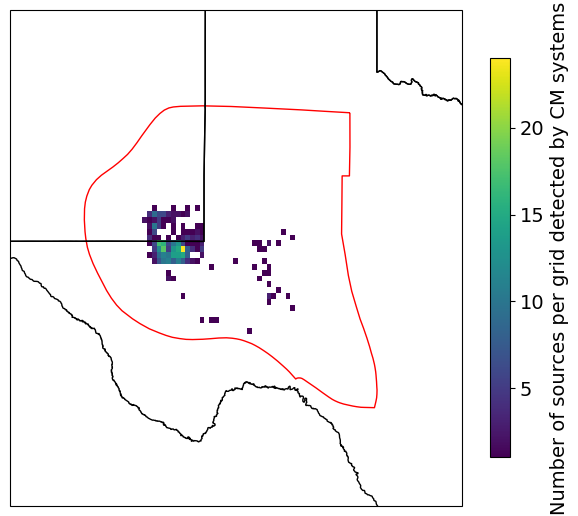

In [29]:
# Set up map projection
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': proj})

# Plot the data using imshow
img = ax.imshow(
    source_counts,
    extent=[west, east, south, north],
    origin='lower',
    transform=proj,
    cmap='viridis'
)

bound_permian.plot(
    ax=ax,
    facecolor='none', 
    edgecolor='red',   
    linewidth=1,
    transform=proj  
)
bound_state.plot(
    ax=ax,
    facecolor='none',  
    edgecolor='black',  
    linewidth=1,
    transform=proj 
)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label("Number of sources per grid detected by CM systems",fontsize=14)
cbar.ax.tick_params(labelsize=14)
ax.set_xlim(west-1, east+1)
ax.set_ylim(south-1, north+1)

plt.tight_layout()
plt.savefig(r"E:\emission_event\Emission-Estimation-Using-Emission-Events\CM_source_counts.png", dpi=600)

In [50]:

emission_2d = np.zeros(np.shape(lon_2d))
emission_2d_upper = np.zeros(np.shape(lon_2d))
emission_2d_lower = np.zeros(np.shape(lon_2d))
for _,row in tdf.iterrows(): 
    x_ind,y_ind = find_indices(row.longitudes,row.latitudes,lon_2d,lat_2d)
    emission_2d[x_ind,y_ind] += row.total_emissions
    emission_2d_upper[x_ind,y_ind] += row.total_emissions_upper
    emission_2d_lower[x_ind,y_ind] += row.total_emissions_lower

In [51]:
emission_2d = np.where(emission_2d== 0, np.nan, emission_2d)

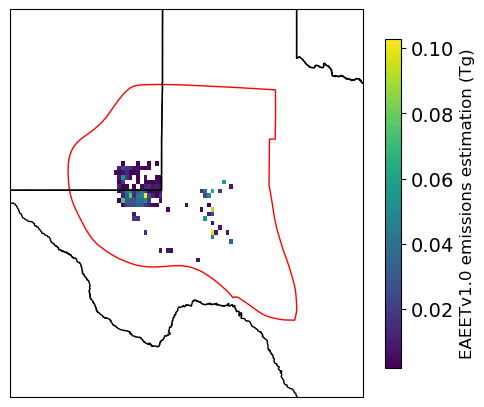

In [53]:
# Set up map projection
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': proj})

# Plot the data using imshow
img = ax.imshow(
    emission_2d*10**-9,
    extent=[west, east, south, north],
    origin='lower',
    transform=proj,
    cmap='viridis'
)

bound_permian.plot(
    ax=ax,
    facecolor='none', 
    edgecolor='red',   
    linewidth=1,
    transform=proj  
)
bound_state.plot(
    ax=ax,
    facecolor='none',  
    edgecolor='black',  
    linewidth=1,
    transform=proj 
)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label("EAEETv1.0 emissions estimation (Tg)", fontsize=12)
cbar.ax.tick_params(labelsize=14)
# Zoom in on Permian
ax.set_xlim(-105.5-1, -99.5+1)
ax.set_ylim(29-1, 34.5+1)
plt.tight_layout()
plt.savefig(r"E:\emission_event\Emission-Estimation-Using-Emission-Events\EAEET_emissions_estimation.png", dpi=600)

### compare emissions from events and GFEI

In [57]:
print(np.nansum(GFEI_masked))
print(np.nansum(GFEI_masked) * np.sqrt(np.nanmean(unc_masked ** 2)))

952540142.8476982
526632548.7771695


In [105]:
(952540142.8476982 + 526632548.7771695) * 10**-9

1.4791726916248678

In [106]:
(952540142.8476982 - 526632548.7771695) * 10**-9

0.4259075940705287

In [107]:
2.36 / 0.9

2.6222222222222222

In [58]:
print(np.nansum(emission_2d_upper))
print(np.nansum(emission_2d_lower))
print(np.nansum(emission_2d))

3345953181.276518
1125832178.1573718
2289886581.9356422


In [59]:
1060625360.9008026
1060625360.9008026 + 1060625360.9008026 * 0.553 
1060625360.9008026 - 1060625360.9008026 * 0.553 

474099536.3226588

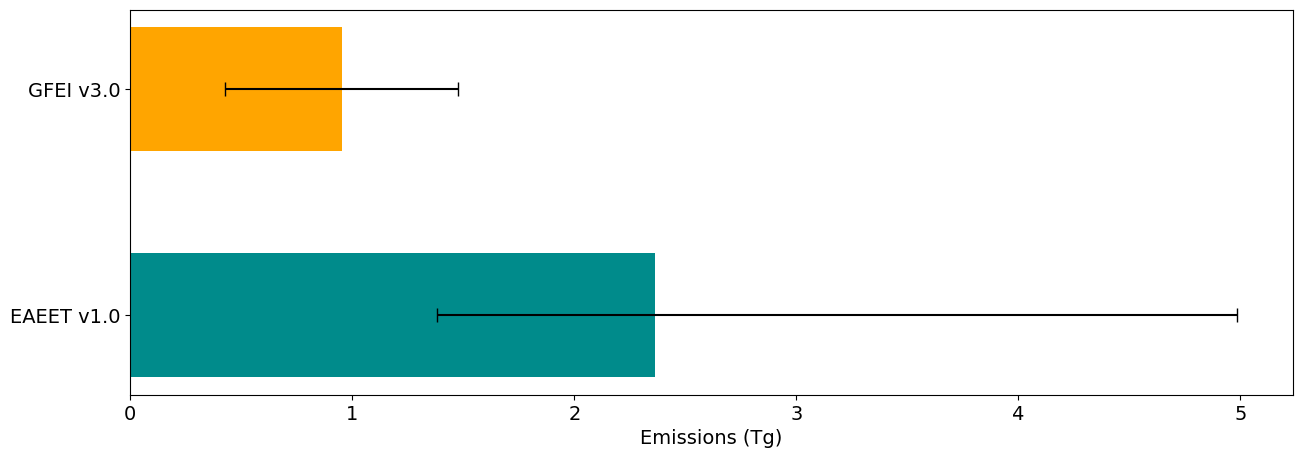

In [109]:
plt.figure(figsize=(15, 5))
categories = [ 'EAEET v1.0', "GFEI v3.0"]
values = [2.364,0.952]
errors = [[2.364 - 1.383 , 0.526],
          [4.987 - 2.364, 0.526]]
bar_width = 0.55
colors = ['darkcyan', 'orange']
index = np.arange(len(categories))
plt.barh(index, values, xerr=errors, height=bar_width, color=colors , capsize=5)
#plt.ylabel('Categories')
plt.xlabel('Emissions (Tg)', fontsize=14)
plt.yticks(index, categories, fontsize=14)
plt.xticks(fontsize=14)
plt.savefig("CM_vs_GFEI.png", dpi=300)